In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

realized_vol = pd.read_csv("../data/realized_volatility.csv", index_col=0, parse_dates=True)
garch_forecasts = pd.read_csv("../data/garch_forecasts.csv", index_col=0, parse_dates=True)
ml_forecasts = pd.read_csv("../data/ml_forecasts.csv", index_col=0, parse_dates=True)

print(f"Realized vol: {realized_vol.shape}, {realized_vol.index.min()} to {realized_vol.index.max()}")
print(f"GARCH forecasts: {garch_forecasts.shape}, {garch_forecasts.index.min()} to {garch_forecasts.index.max()}")
print(f"ML forecasts: {ml_forecasts.shape}, {ml_forecasts.index.min()} to {ml_forecasts.index.max()}")
print(f"\nML forecast columns: {list(ml_forecasts.columns)}")

Realized vol: (1992, 4), 2017-02-01 00:00:00 to 2024-12-31 00:00:00
GARCH forecasts: (2669, 4), 2017-09-11 00:00:00 to 2024-12-31 00:00:00
ML forecasts: (1759, 12), 2018-01-04 00:00:00 to 2024-12-31 00:00:00

ML forecast columns: ['spx_low', 'spx_mid', 'spx_high', 'stable_low', 'stable_mid', 'stable_high', 'tech_low', 'tech_mid', 'tech_high', 'btc_low', 'btc_mid', 'btc_high']


In [2]:
def qlike(pred_vol, actual_vol):
    aligned = pd.concat([pred_vol, actual_vol], axis=1, join="inner").dropna()
    aligned.columns = ["pred", "actual"]
    
    # Convert volatility to variance for the QLIKE formula
    pred_var = aligned["pred"] ** 2
    actual_var = aligned["actual"] ** 2
    
    # Guard against zero/negative predictions before taking log
    pred_var = pred_var.clip(lower=1e-8)
    
    ratio = actual_var / pred_var
    qlike_values = ratio - np.log(ratio) - 1
    
    return qlike_values.mean()

def rmse(pred, actual):
    aligned = pd.concat([pred, actual], axis=1, join="inner").dropna()
    aligned.columns = ["pred", "actual"]
    return np.sqrt(((aligned["pred"] - aligned["actual"]) ** 2).mean())

# Quick sanity check: QLIKE of a series against itself should be ~0
test_series = realized_vol["spx"]
print(f"QLIKE of SPX realized vol against itself (should be ~0): {qlike(test_series, test_series):.6f}")

QLIKE of SPX realized vol against itself (should be ~0): 0.000000


In [3]:
assets = ["spx", "stable", "tech", "btc"]
results = []

for asset in assets:
    garch_pred = garch_forecasts[asset]
    ml_pred = ml_forecasts[f"{asset}_mid"]
    actual = realized_vol[asset]
    
    results.append({
        "asset": asset,
        "garch_rmse": rmse(garch_pred, actual),
        "ml_rmse": rmse(ml_pred, actual),
        "garch_qlike": qlike(garch_pred, actual),
        "ml_qlike": qlike(ml_pred, actual)
    })

results_df = pd.DataFrame(results).set_index("asset")
results_df

,garch_rmse,ml_rmse,garch_qlike,ml_qlike
asset,,,,
spx,8.592860,3.201946,0.365540,0.082860
stable,5.279818,4.549266,0.130254,0.074513
tech,15.684689,3.908733,0.222551,0.011205
btc,21.916048,4.633181,0.241216,0.018709


In [4]:
periods = {
    "Pre-2020 (calm)": ("2017-01-01", "2020-01-31"),
    "COVID crash": ("2020-02-01", "2020-06-30"),
    "2021-2022 grind": ("2021-01-01", "2022-12-31"),
    "Recent (2023-2024)": ("2023-01-01", "2024-12-31")
}

period_results = []

for period_name, (start, end) in periods.items():
    for asset in assets:
        garch_pred = garch_forecasts[asset].loc[start:end]
        ml_pred = ml_forecasts[f"{asset}_mid"].loc[start:end]
        actual = realized_vol[asset].loc[start:end]
        
        if len(actual.dropna()) < 5:  # skip if barely any data in this window for this asset
            continue
        
        period_results.append({
            "period": period_name,
            "asset": asset,
            "garch_rmse": rmse(garch_pred, actual),
            "ml_rmse": rmse(ml_pred, actual),
            "garch_qlike": qlike(garch_pred, actual),
            "ml_qlike": qlike(ml_pred, actual)
        })

period_results_df = pd.DataFrame(period_results)
period_results_df

,period,asset,garch_rmse,ml_rmse,garch_qlike,ml_qlike
0,Pre-2020 (calm),spx,6.978281,2.877121,0.465696,0.195864
1,Pre-2020 (calm),stable,4.356245,2.034267,0.179164,0.047671
2,Pre-2020 (calm),tech,17.016262,2.915230,0.321755,0.010931
3,Pre-2020 (calm),btc,26.015347,4.484685,0.298162,0.026367
4,COVID crash,spx,20.259148,11.351828,0.411371,0.378643
5,COVID crash,stable,14.748948,17.842144,0.306408,0.978671
6,COVID crash,tech,20.312950,13.820465,0.259141,0.101891
7,COVID crash,btc,37.304726,12.386108,0.494661,0.064059
8,2021-2022 grind,spx,7.785613,0.631242,0.277830,0.004429
9,2021-2022 grind,stable,4.029421,0.770764,0.100684,0.003344


In [5]:
from arch import arch_model
from scipy import stats

def rolling_garch_quantiles(returns, refit_every=21, dist='t', quantiles=[0.1, 0.9]):
    scaled_returns = returns * 100
    start = 252
    
    results = []
    
    for i in range(start, len(scaled_returns), refit_every):
        train_data = scaled_returns.iloc[:i]
        
        model = arch_model(train_data, vol='GARCH', p=1, q=1, dist=dist)
        fitted = model.fit(disp='off')
        
        horizon = min(refit_every, len(scaled_returns) - i)
        forecast = fitted.forecast(horizon=horizon, reindex=False)
        variances = forecast.variance.values[0]
        
        # Get the fitted degrees-of-freedom parameter for the Student-t distribution
        nu = fitted.params['nu']
        
        for h in range(horizon):
            date = scaled_returns.index[i + h]
            std_dev = np.sqrt(variances[h])
            
            # Student-t quantiles, scaled by the forecasted std dev
            row = {"date": date}
            for q in quantiles:
                t_quantile = stats.t.ppf(q, df=nu)
                # Scale t-quantile to have the right variance (t distribution has variance nu/(nu-2))
                scale_adj = np.sqrt((nu - 2) / nu)
                row[f"q{int(q*100)}"] = std_dev * t_quantile * scale_adj
            results.append(row)
    
    return pd.DataFrame(results).set_index("date")

# Test on SPX only first
spx = pd.read_csv("../data/spx.csv", index_col=0, parse_dates=True)
spx_returns = np.log(spx["Close"] / spx["Close"].shift(1)).dropna()

spx_garch_quantiles = rolling_garch_quantiles(spx_returns)
print(f"Generated {len(spx_garch_quantiles)} rows")
spx_garch_quantiles.head()

Generated 1759 rows


,q10,q90
date,,
2018-01-04,-0.479066,0.479066
2018-01-05,-0.466665,0.466665
2018-01-08,-0.463425,0.463425
2018-01-09,-0.462589,0.462589
2018-01-10,-0.462374,0.462374


Generated 1759 rows


,q10,q90
date,,
2018-01-04,-0.479066,0.479066
2018-01-05,-0.466665,0.466665
2018-01-08,-0.463425,0.463425
2018-01-09,-0.462589,0.462589
2018-01-10,-0.462374,0.462374


In [6]:
# Convert to annualized volatility interval
spx_garch_quantiles_vol = pd.DataFrame({
    "garch_low": spx_garch_quantiles["q10"].abs() / 100 * np.sqrt(252) * 100,
    "garch_high": spx_garch_quantiles["q90"].abs() / 100 * np.sqrt(252) * 100
})

# Since q10 and q90 are symmetric, low and high will be identical -- that's expected and worth noting
spx_garch_quantiles_vol.head()

,garch_low,garch_high
date,,
2018-01-04,7.604934,7.604934
2018-01-05,7.408075,7.408075
2018-01-08,7.356644,7.356644
2018-01-09,7.343371,7.343371
2018-01-10,7.339957,7.339957


In [7]:
def rolling_garch_quantiles_sim(returns, refit_every=21, dist='t', quantiles=[0.1, 0.9], n_sims=1000):
    scaled_returns = returns * 100
    start = 252
    
    results = []
    
    for i in range(start, len(scaled_returns), refit_every):
        train_data = scaled_returns.iloc[:i]
        
        model = arch_model(train_data, vol='GARCH', p=1, q=1, dist=dist)
        fitted = model.fit(disp='off')
        
        horizon = min(refit_every, len(scaled_returns) - i)
        # Simulation method generates many possible future paths, giving a real distribution of variance outcomes
        forecast = fitted.forecast(horizon=horizon, reindex=False, method='simulation', simulations=n_sims)
        
        # sim_variances shape: (1, n_sims, horizon)
        sim_variances = forecast.simulations.variances[0]
        
        for h in range(horizon):
            date = scaled_returns.index[i + h]
            # Take quantiles ACROSS simulations for this specific horizon day
            var_samples = sim_variances[:, h]
            vol_samples = np.sqrt(var_samples)
            
            row = {"date": date}
            for q in quantiles:
                row[f"q{int(q*100)}"] = np.quantile(vol_samples, q)
            results.append(row)
    
    return pd.DataFrame(results).set_index("date")

# Test on SPX only -- this will be noticeably slower due to simulation
spx_garch_quantiles = rolling_garch_quantiles_sim(spx_returns)
print(f"Generated {len(spx_garch_quantiles)} rows")
spx_garch_quantiles.head()

Generated 1759 rows


,q10,q90
date,,
2018-01-04,0.505003,0.505003
2018-01-05,0.461353,0.514519
2018-01-08,0.455384,0.512429
2018-01-09,0.454793,0.517261
2018-01-10,0.454733,0.507895


In [8]:
spx_garch_quantiles_vol = pd.DataFrame({
    "garch_low": spx_garch_quantiles["q10"] / 100 * np.sqrt(252) * 100,
    "garch_high": spx_garch_quantiles["q90"] / 100 * np.sqrt(252) * 100
})

spx_garch_quantiles_vol.head()

,garch_low,garch_high
date,,
2018-01-04,8.016677,8.016677
2018-01-05,7.323757,8.167738
2018-01-08,7.228998,8.134563
2018-01-09,7.219619,8.211270
2018-01-10,7.218669,8.062581


In [9]:
merged_check = pd.concat([spx_garch_quantiles_vol, realized_vol["spx"]], axis=1, join="inner").dropna()
merged_check.columns = ["garch_low", "garch_high", "actual"]

inside_interval = (merged_check["actual"] >= merged_check["garch_low"]) & (merged_check["actual"] <= merged_check["garch_high"])
coverage = inside_interval.mean() * 100

print(f"GARCH SPX 10-90% interval coverage: {coverage:.1f}% (target: ~80%)")

# Compare to ML's already-known coverage
ml_merged = pd.concat([ml_forecasts[["spx_low", "spx_high"]], realized_vol["spx"]], axis=1, join="inner").dropna()
ml_merged.columns = ["ml_low", "ml_high", "actual"]
ml_inside = (ml_merged["actual"] >= ml_merged["ml_low"]) & (ml_merged["actual"] <= ml_merged["ml_high"])
ml_coverage = ml_inside.mean() * 100

print(f"ML SPX 10-90% interval coverage: {ml_coverage:.1f}% (target: ~80%)")

GARCH SPX 10-90% interval coverage: 49.5% (target: ~80%)
ML SPX 10-90% interval coverage: 81.7% (target: ~80%)


In [10]:
stable = pd.read_csv("../data/stable.csv", index_col=0, parse_dates=True)
tech = pd.read_csv("../data/tech.csv", index_col=0, parse_dates=True)
btc = pd.read_csv("../data/btc.csv", index_col=0, parse_dates=True)

stable_returns = np.log(stable["Close"] / stable["Close"].shift(1)).dropna()
tech_returns = np.log(tech["Close"] / tech["Close"].shift(1)).dropna()
btc_returns = np.log(btc["Close"] / btc["Close"].shift(1)).dropna()

print("Running Stable...")
stable_garch_quantiles = rolling_garch_quantiles_sim(stable_returns)
print(f"Stable: {len(stable_garch_quantiles)} rows")

print("Running Tech...")
tech_garch_quantiles = rolling_garch_quantiles_sim(tech_returns)
print(f"Tech: {len(tech_garch_quantiles)} rows")

print("Running BTC...")
btc_garch_quantiles = rolling_garch_quantiles_sim(btc_returns)
print(f"BTC: {len(btc_garch_quantiles)} rows")

Running Stable...
Stable: 1759 rows
Running Tech...
Tech: 1759 rows
Running BTC...
BTC: 2669 rows


In [11]:
def annualize_quantiles(quantiles_df):
    return pd.DataFrame({
        "garch_low": quantiles_df["q10"] / 100 * np.sqrt(252) * 100,
        "garch_high": quantiles_df["q90"] / 100 * np.sqrt(252) * 100
    })

stable_garch_quantiles_vol = annualize_quantiles(stable_garch_quantiles)
tech_garch_quantiles_vol = annualize_quantiles(tech_garch_quantiles)
btc_garch_quantiles_vol = annualize_quantiles(btc_garch_quantiles)

all_garch_quantiles = {
    "spx": spx_garch_quantiles_vol,
    "stable": stable_garch_quantiles_vol,
    "tech": tech_garch_quantiles_vol,
    "btc": btc_garch_quantiles_vol
}

coverage_results = []

for asset in assets:
    garch_q = all_garch_quantiles[asset]
    garch_merged = pd.concat([garch_q, realized_vol[asset]], axis=1, join="inner").dropna()
    garch_merged.columns = ["garch_low", "garch_high", "actual"]
    garch_coverage = ((garch_merged["actual"] >= garch_merged["garch_low"]) & 
                       (garch_merged["actual"] <= garch_merged["garch_high"])).mean() * 100
    
    ml_merged = pd.concat([ml_forecasts[[f"{asset}_low", f"{asset}_high"]], realized_vol[asset]], axis=1, join="inner").dropna()
    ml_merged.columns = ["ml_low", "ml_high", "actual"]
    ml_coverage = ((ml_merged["actual"] >= ml_merged["ml_low"]) & 
                    (ml_merged["actual"] <= ml_merged["ml_high"])).mean() * 100
    
    coverage_results.append({"asset": asset, "garch_coverage": garch_coverage, "ml_coverage": ml_coverage})

coverage_df = pd.DataFrame(coverage_results).set_index("asset")
coverage_df

,garch_coverage,ml_coverage
asset,,
spx,49.516771,81.694144
stable,57.077885,81.580443
tech,43.263218,80.613985
btc,46.057640,82.035247


In [12]:
crash_start, crash_end = "2020-02-01", "2020-06-30"

crash_coverage_results = []

for asset in assets:
    garch_q = all_garch_quantiles[asset].loc[crash_start:crash_end]
    ml_q = ml_forecasts[[f"{asset}_low", f"{asset}_high"]].loc[crash_start:crash_end]
    actual = realized_vol[asset].loc[crash_start:crash_end]
    
    garch_merged = pd.concat([garch_q, actual], axis=1, join="inner").dropna()
    garch_merged.columns = ["garch_low", "garch_high", "actual"]
    
    ml_merged = pd.concat([ml_q, actual], axis=1, join="inner").dropna()
    ml_merged.columns = ["ml_low", "ml_high", "actual"]
    
    if len(garch_merged) < 3 or len(ml_merged) < 3:
        continue
    
    garch_coverage = ((garch_merged["actual"] >= garch_merged["garch_low"]) & 
                       (garch_merged["actual"] <= garch_merged["garch_high"])).mean() * 100
    ml_coverage = ((ml_merged["actual"] >= ml_merged["ml_low"]) & 
                    (ml_merged["actual"] <= ml_merged["ml_high"])).mean() * 100
    
    crash_coverage_results.append({
        "asset": asset, 
        "garch_coverage_crash": garch_coverage, 
        "ml_coverage_crash": ml_coverage,
        "n_days": len(garch_merged)
    })

crash_coverage_df = pd.DataFrame(crash_coverage_results).set_index("asset")
crash_coverage_df

,garch_coverage_crash,ml_coverage_crash,n_days
asset,,,
spx,55.769231,72.115385,104
stable,58.653846,59.615385,104
tech,64.423077,63.461538,104
btc,28.846154,62.500000,104


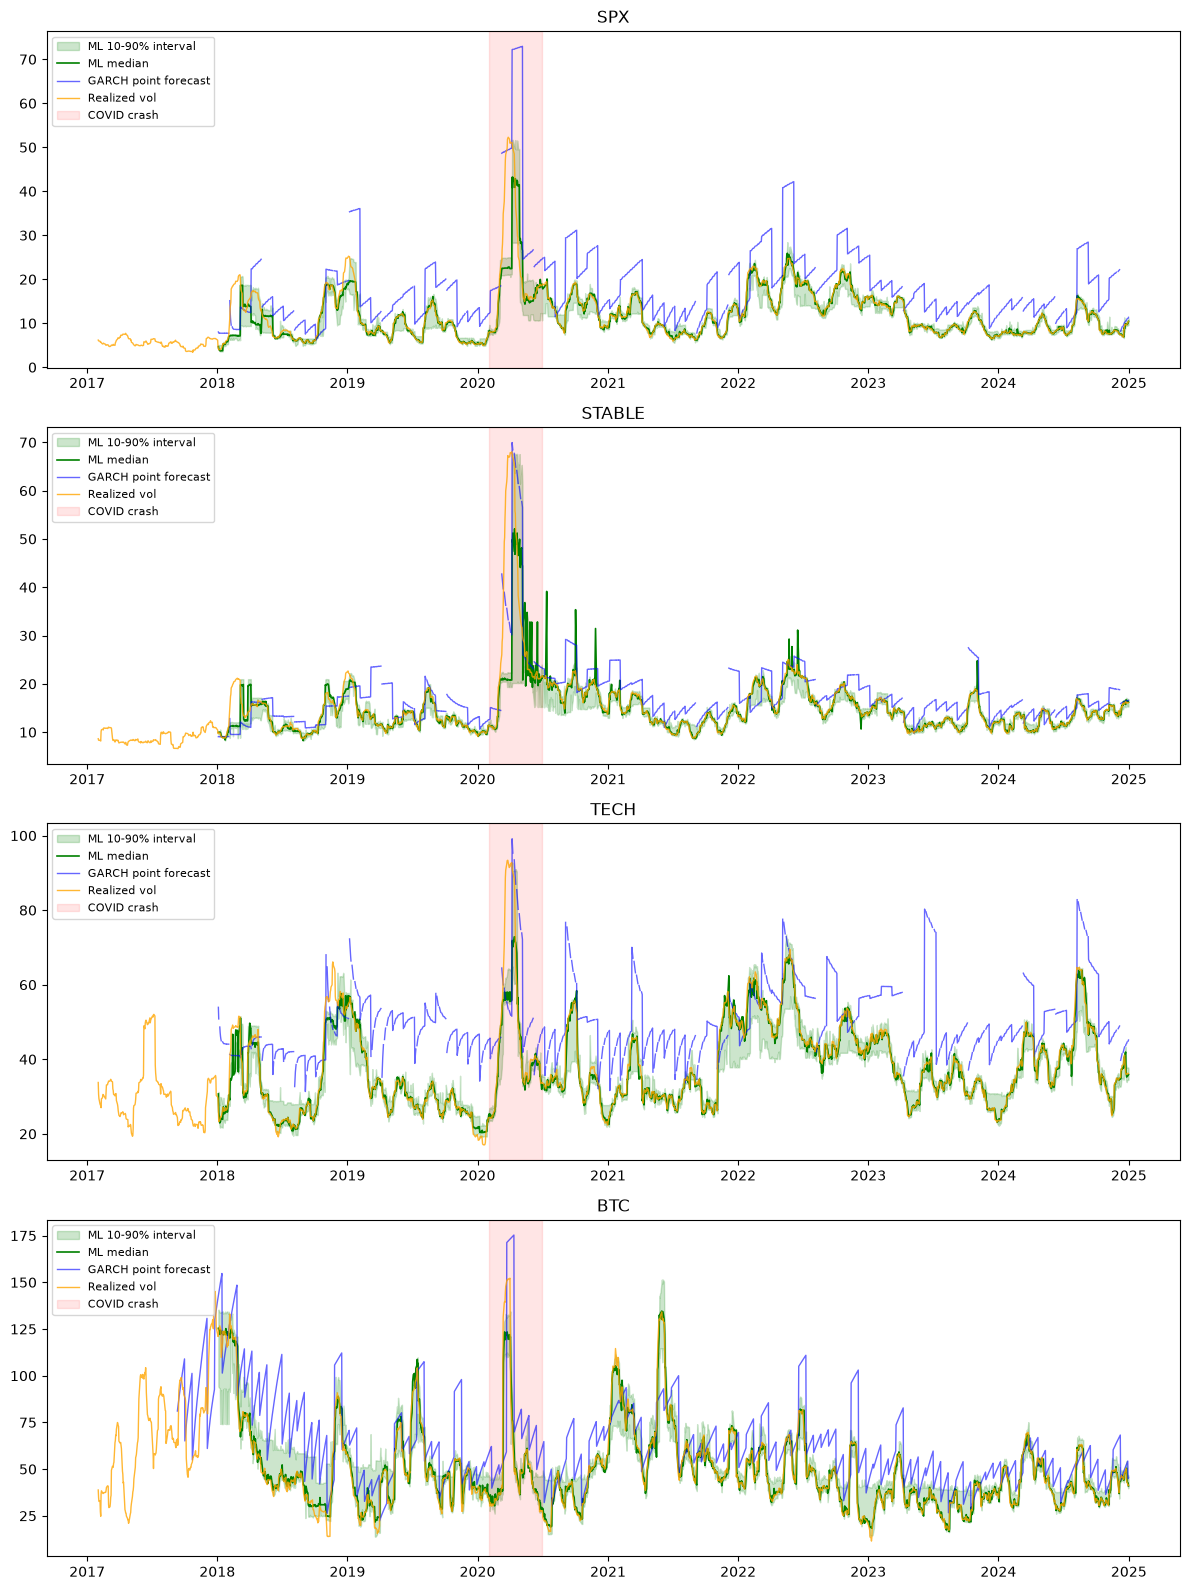

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

for ax, asset in zip(axes, assets):
    garch_q = all_garch_quantiles[asset]
    
    ax.fill_between(ml_forecasts.index, ml_forecasts[f"{asset}_low"], ml_forecasts[f"{asset}_high"],
                     alpha=0.2, color="green", label="ML 10-90% interval")
    ax.plot(ml_forecasts.index, ml_forecasts[f"{asset}_mid"], color="green", label="ML median", linewidth=1.2)
    ax.plot(garch_forecasts.index, garch_forecasts[asset], color="blue", alpha=0.6, label="GARCH point forecast", linewidth=1)
    ax.plot(realized_vol.index, realized_vol[asset], color="orange", alpha=0.8, label="Realized vol", linewidth=1)
    
    # Mark the COVID crash period
    ax.axvspan(pd.Timestamp(crash_start), pd.Timestamp(crash_end), alpha=0.1, color="red", label="COVID crash")
    
    ax.set_title(asset.upper())
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## Summary of Findings

**Overall accuracy:** ML (LightGBM, quantile regression) outperforms GARCH(1,1) on both RMSE and QLIKE across all 4 assets, with the largest gains on the most erratic assets (Tech, BTC) and the smallest gain on the calmest asset (Stable).

**Calibration:** ML's 10-90% prediction intervals are well-calibrated overall (80.6-82.0% empirical coverage, close to the 80% target) across all 4 assets. GARCH's intervals, derived via Monte Carlo simulation from its fitted Student-t distribution, are severely miscalibrated — only 43-57% empirical coverage — meaning GARCH understates its own forecast uncertainty by a wide margin.

**The COVID crash is the key exception:** during the Feb-Jun 2020 crash, both models' accuracy and calibration degrade, but the degradation is uneven. On Stable specifically, ML's RMSE and QLIKE are actually worse than GARCH's during this window, and ML's median forecast becomes visibly unstable — likely because ML's heavy reliance on very recent lagged realized volatility (its single most important feature) becomes a liability when volatility itself is moving faster than those lagged inputs can reflect. GARCH's structural mean-reversion mechanism, despite being worse everywhere else, provides a real (if partial) advantage in this specific regime-shift scenario.

**Takeaway:** a flexible ML model that directly exploits volatility's own autocorrelation outperforms GARCH in typical and moderately volatile conditions, and gives genuinely trustworthy uncertainty estimates where GARCH does not — but this advantage is not universal, and during sudden, severe regime shifts, GARCH's simpler structural assumptions can still hold real value, particularly for assets with limited historical experience of such shocks.